# LoanLens — Explainability with SHAP

We have established the baseline behaviour of LoanLens:

- Logistic Regression performs slightly better than Random Forest.
- Overall predictive performance is around 98%.
- Removing `Credit_History` reduces performance to approximately chance level.
- SHAP can now help us understand **why the model makes individual decisions**.

This notebook builds the explainability layer and prepares the project for the counterfactual engine.

### Pipeline

```text
Trained model
     ↓
Save model
     ↓
Transform features
     ↓
SHAP
     ↓
Global feature importance
     ↓
Group one-hot features
     ↓
Explain an individual applicant
     ↓
Human-readable explanation
     ↓
Counterfactual engine
```

> SHAP explains model behaviour. It does not establish causation or represent an actual bank's underwriting policy.


## 1. Install additional packages

Run this once in the LoanLens virtual environment if needed:

```text
python -m pip install shap joblib
```

If packages were installed while the notebook was open, restart the `.venv (3.11.9)` kernel before continuing.


In [18]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid")


## 2. Load the dataset

The raw CSV remains unchanged in:

`data/raw/loan_approval.csv`


In [19]:
project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "raw" / "loan_approval.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path}\n"
        "Make sure loan_approval.csv is inside data/raw/."
    )

df = pd.read_csv(data_path)

print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")


Loaded 3,192 rows × 14 columns


## 3. Define features and target

`Loan_ID` is an identifier and is excluded from the model.

`Loan_Status` is the target we want to predict.


In [20]:
X = df.drop(columns=["Loan_Status", "Loan_ID"])
y = df["Loan_Status"]

numerical_features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Term",
    "Age",
]

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Employment_Status",
    "Credit_History",
    "Property_Area",
]

print("Features:", X.columns.tolist())
print("Target classes:", y.unique())


Features: ['Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age']
Target classes: <StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str


## 4. Recreate the preprocessing pipeline

We reproduce the same leakage-safe preprocessing strategy used in the baseline notebook.

Numerical:
- median imputation
- standard scaling

Categorical:
- most-frequent imputation
- one-hot encoding


In [21]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])


## 5. Reproduce the baseline train/test split

We use the same `random_state` and stratification as the baseline notebook so the explainability analysis remains consistent with the model evaluation.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 2553
Test rows: 639


## 6. Train the selected Logistic Regression model

Logistic Regression was the stronger baseline in our experiment.

It is also useful for explainability because its additive structure is straightforward to inspect.


In [23]:
loanlens_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000)),
])

loanlens_model.fit(X_train, y_train)

classifier = loanlens_model.named_steps["model"]

print("Classes:", classifier.classes_)
print("Model trained successfully.")


Classes: ['Approved' 'Rejected']
Model trained successfully.


## 7. Persist the model

The complete pipeline is saved rather than only the classifier.

That means the backend can later load:

```text
raw application
      ↓
preprocessing
      ↓
model
      ↓
prediction
```

without retraining the model for every request.


In [24]:
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "loanlens_logistic_pipeline.joblib"

joblib.dump(loanlens_model, model_path)

print(f"Saved model to: {model_path}")


Saved model to: D:\PROJECTS\loanlens\models\loanlens_logistic_pipeline.joblib


## 8. Verify model persistence

We load the saved model and verify that it produces the same predictions as the original pipeline.


In [25]:
loaded_model = joblib.load(model_path)

original_predictions = loanlens_model.predict(X_test.head(10))
loaded_predictions = loaded_model.predict(X_test.head(10))

print(
    "Predictions identical:",
    np.array_equal(original_predictions, loaded_predictions)
)


Predictions identical: True


## 9. Transform data for SHAP

The Logistic Regression model receives the **preprocessed** feature matrix rather than the original dataframe.

One-hot encoding can turn one business feature into multiple model features.

For example:

```text
Credit_History
      ↓
Credit_History_0
Credit_History_1
```

We retrieve the transformed feature names so we can connect SHAP results back to their original meaning.


In [26]:
fitted_preprocessor = loanlens_model.named_steps["preprocessor"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

print("Training matrix:", X_train_transformed.shape)
print("Test matrix:", X_test_transformed.shape)
print("Transformed features:", len(feature_names))


Training matrix: (2553, 23)
Test matrix: (639, 23)
Transformed features: 23


## 10. Generate SHAP values

SHAP assigns each transformed feature a contribution to the model output for each application.

We use `LinearExplainer` because our selected model is Logistic Regression.


In [27]:
explainer = shap.LinearExplainer(
    classifier,
    X_train_transformed
)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values generated.")
print("SHAP shape:", np.asarray(shap_values).shape)


SHAP values generated.
SHAP shape: (639, 23)


## 11. Identify the Approved class safely

Scikit-learn stores class ordering in `classes_`.

We explicitly locate `Approved` instead of assuming a fixed probability column.


In [28]:
approved_index = list(classifier.classes_).index("Approved")

approval_probabilities = loanlens_model.predict_proba(X_test)[:, approved_index]

print("Approved class index:", approved_index)
print("First 10 approval probabilities:")
print(np.round(approval_probabilities[:10], 3))


Approved class index: 0
First 10 approval probabilities:
[0.95  0.991 0.001 0.999 0.    0.997 0.031 0.937 0.    0.954]


## 12. Prepare SHAP values for the Approved class

Depending on the SHAP version/model output, SHAP values can be returned in slightly different shapes.

The code below normalizes the result so the remaining analysis consistently explains the `Approved` output.


In [29]:
shap_array = np.asarray(shap_values)

if shap_array.ndim == 3:
    shap_for_plot = shap_array[:, :, approved_index]
else:
    shap_for_plot = shap_array

print("Normalized SHAP shape:", shap_for_plot.shape)


Normalized SHAP shape: (639, 23)


## 13. Global SHAP importance

Global importance asks:

> **Across all test applications, which transformed features have the largest average contribution magnitude?**

We use mean absolute SHAP values so positive and negative contributions do not cancel each other out.


In [30]:
mean_abs_shap = np.abs(shap_for_plot).mean(axis=0)

global_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(global_importance.head(15))


,feature,mean_abs_shap
0,cat__Credit_History_0,3.0006
1,cat__Credit_History_1,2.9988
2,num__Applicant_Income,0.7568
3,num__Coapplicant_Income,0.6483
4,cat__Employment_Status_Salaried,0.6166
5,num__Loan_Amount,0.5177
6,cat__Property_Area_Urban,0.3669
7,cat__Property_Area_Semiurban,0.2978
8,cat__Employment_Status_Self-Employed,0.2934
9,cat__Education_Not Graduate,0.2525


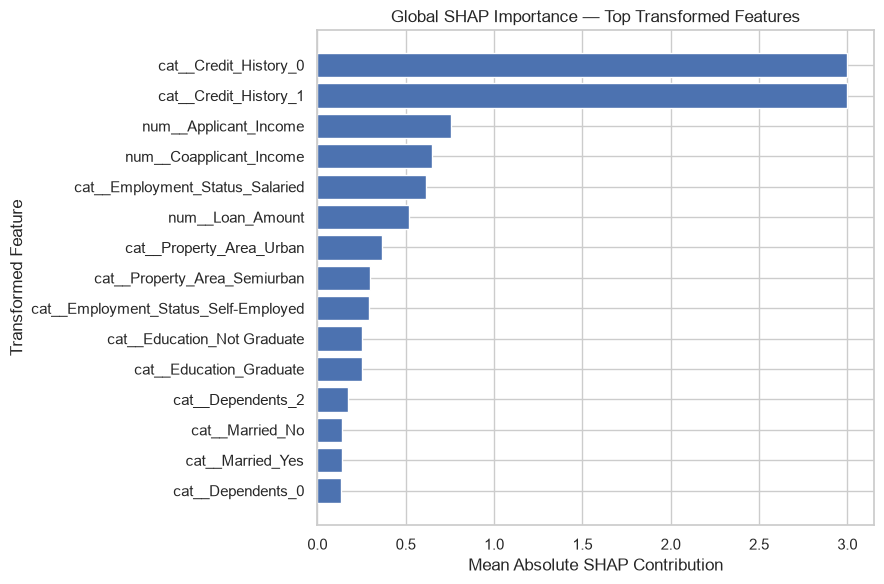

In [31]:
plot_data = global_importance.head(15).sort_values("mean_abs_shap")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["feature"],
    plot_data["mean_abs_shap"]
)

plt.title("Global SHAP Importance — Top Transformed Features")
plt.xlabel("Mean Absolute SHAP Contribution")
plt.ylabel("Transformed Feature")

plt.tight_layout()
plt.show()


## 14. Group SHAP values by original business feature

This is important for LoanLens.

One-hot encoding splits categorical features into several model features.

For example:

```text
Credit_History_0
Credit_History_1
```

are both parts of the original business feature:

```text
Credit_History
```

A user should not see two separate "Credit History" entries.

We therefore aggregate the absolute SHAP contributions of transformed columns back to their original features.


In [32]:
grouped_importance = []

all_original_features = numerical_features + categorical_features

for original_feature in all_original_features:
    matching_columns = [
        i
        for i, name in enumerate(feature_names)
        if original_feature in name
    ]

    if not matching_columns:
        continue

    grouped_values = np.abs(
        shap_for_plot[:, matching_columns]
    ).sum(axis=1)

    grouped_importance.append({
        "feature": original_feature,
        "mean_abs_shap": grouped_values.mean(),
    })

grouped_importance = (
    pd.DataFrame(grouped_importance)
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(grouped_importance)


,feature,mean_abs_shap
0,Credit_History,5.9994
1,Employment_Status,0.9656
2,Applicant_Income,0.7568
3,Property_Area,0.6870
4,Coapplicant_Income,0.6483
5,Loan_Amount,0.5177
6,Education,0.5038
7,Dependents,0.3749
8,Married,0.2775
9,Age,0.0610


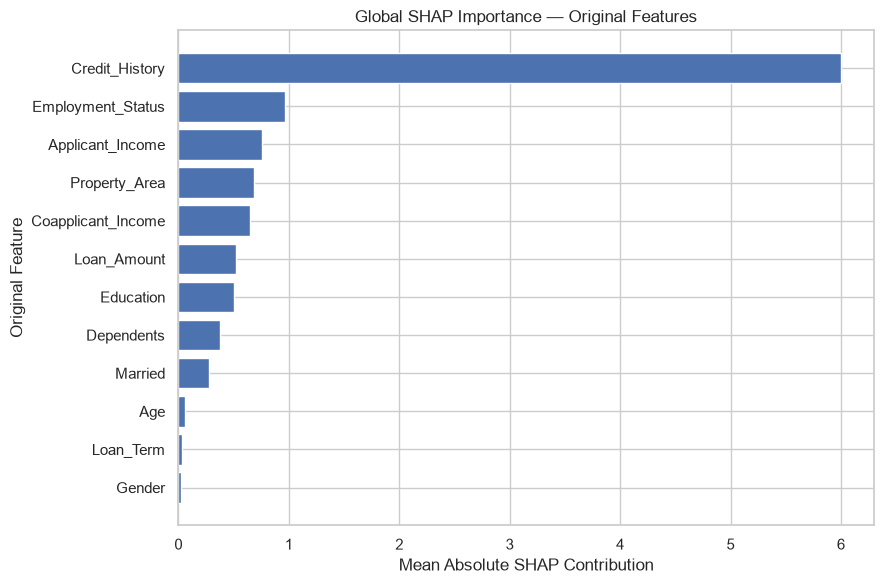

In [33]:
plot_grouped = grouped_importance.sort_values("mean_abs_shap")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_grouped["feature"],
    plot_grouped["mean_abs_shap"]
)

plt.title("Global SHAP Importance — Original Features")
plt.xlabel("Mean Absolute SHAP Contribution")
plt.ylabel("Original Feature")

plt.tight_layout()
plt.show()


### Interpretation

This grouped analysis is the more appropriate one for the LoanLens product layer.

If `Credit_History` remains dramatically above the other original features, SHAP independently confirms our earlier EDA and ablation experiment:

> **Credit_History is the dominant predictive signal in this dataset.**

This does not mean it is causal, and it does not mean every real-world bank uses the same relationship.


## 15. Select one individual application

Global SHAP importance tells us what the model generally uses.

LoanLens also needs to answer:

> **Why did the model make this particular decision?**

We select the first application from the held-out test set.


In [34]:
sample_position = 0

sample_application = X_test.iloc[[sample_position]]
sample_actual = y_test.iloc[sample_position]
sample_prediction = loanlens_model.predict(sample_application)[0]
sample_probability = loanlens_model.predict_proba(
    sample_application
)[0, approved_index]

print("Actual status:", sample_actual)
print("Predicted status:", sample_prediction)
print(f"Approval probability: {sample_probability:.2%}")

display(
    sample_application.T.rename(
        columns={sample_application.index[0]: "Value"}
    )
)


Actual status: Approved
Predicted status: Approved
Approval probability: 94.97%


,Value
Gender,Male
Married,Yes
Dependents,1
Education,NaN
Employment_Status,Unemployed
Applicant_Income,"39,484.9463"
Coapplicant_Income,0.0000
Loan_Amount,"136,066.7614"
Loan_Term,60
Credit_History,1


## 16. Individual SHAP contributions

We rank the transformed features by the magnitude of their contribution for this specific applicant.


In [35]:
sample_shap = shap_for_plot[sample_position]

individual_explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": sample_shap,
})

individual_explanation["absolute_impact"] = (
    individual_explanation["shap_value"].abs()
)

individual_explanation = (
    individual_explanation
    .sort_values("absolute_impact", ascending=False)
    .reset_index(drop=True)
)

display(individual_explanation.head(15))


,feature,shap_value,absolute_impact
0,cat__Credit_History_0,-2.7154,2.7154
1,cat__Credit_History_1,-2.7138,2.7138
2,num__Coapplicant_Income,1.4003,1.4003
3,cat__Employment_Status_Salaried,1.0404,1.0404
4,num__Applicant_Income,0.9507,0.9507
5,cat__Employment_Status_Unemployed,0.6930,0.6930
6,cat__Property_Area_Urban,-0.3669,0.3669
7,cat__Property_Area_Semiurban,-0.2432,0.2432
8,num__Loan_Amount,-0.2303,0.2303
9,cat__Employment_Status_Self-Employed,-0.2057,0.2057


## 17. Human-readable feature names

The model sees technical names such as:

`cat__Property_Area_Urban`

The LoanLens frontend should eventually display:

`Property Area → Urban`

This translation layer separates ML implementation details from the user experience.


In [36]:
def humanize_feature(feature_name: str) -> str:
    feature_name = feature_name.replace("num__", "")
    feature_name = feature_name.replace("cat__", "")

    for original_feature in categorical_features:
        prefix = original_feature + "_"
        if feature_name.startswith(prefix):
            value = feature_name[len(prefix):]
            return f"{original_feature} → {value}"

    return feature_name

human_readable = individual_explanation.head(10).copy()

human_readable["human_feature"] = human_readable[
    "feature"
].apply(humanize_feature)

human_readable["direction"] = np.where(
    human_readable["shap_value"] >= 0,
    "Pushes toward Approved",
    "Pushes away from Approved",
)

display(
    human_readable[
        ["human_feature", "shap_value", "direction"]
    ]
)


,human_feature,shap_value,direction
0,Credit_History → 0,-2.7154,Pushes away from Approved
1,Credit_History → 1,-2.7138,Pushes away from Approved
2,Coapplicant_Income,1.4003,Pushes toward Approved
3,Employment_Status → Salaried,1.0404,Pushes toward Approved
4,Applicant_Income,0.9507,Pushes toward Approved
5,Employment_Status → Unemployed,0.6930,Pushes toward Approved
6,Property_Area → Urban,-0.3669,Pushes away from Approved
7,Property_Area → Semiurban,-0.2432,Pushes away from Approved
8,Loan_Amount,-0.2303,Pushes away from Approved
9,Employment_Status → Self-Employed,-0.2057,Pushes away from Approved


## 18. Build a simple explanation object

This is the beginning of the backend response format.

Instead of exposing raw SHAP arrays to the frontend, the API can eventually return structured information such as:

```text
prediction
approval_probability
top_positive_factors
top_negative_factors
```

The frontend team can then render this however they want.


In [37]:
top_positive = (
    individual_explanation[
        individual_explanation["shap_value"] > 0
    ]
    .head(5)
    .copy()
)

top_negative = (
    individual_explanation[
        individual_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value")
    .head(5)
    .copy()
)

explanation = {
    "prediction": sample_prediction,
    "approval_probability": float(sample_probability),
    "positive_factors": [
        {
            "feature": humanize_feature(row["feature"]),
            "shap_value": float(row["shap_value"]),
        }
        for _, row in top_positive.iterrows()
    ],
    "negative_factors": [
        {
            "feature": humanize_feature(row["feature"]),
            "shap_value": float(row["shap_value"]),
        }
        for _, row in top_negative.iterrows()
    ],
}

explanation


{'prediction': 'Approved',
 'approval_probability': 0.9497358180250588,
 'positive_factors': [{'feature': 'Coapplicant_Income',
   'shap_value': 1.4003342344248377},
  {'feature': 'Employment_Status → Salaried',
   'shap_value': 1.0403620627226888},
  {'feature': 'Applicant_Income', 'shap_value': 0.9507422934207314},
  {'feature': 'Employment_Status → Unemployed',
   'shap_value': 0.6930297310233934},
  {'feature': 'Dependents → 0', 'shap_value': 0.11142027444183147}],
 'negative_factors': [{'feature': 'Credit_History → 0',
   'shap_value': -2.7154439796564445},
  {'feature': 'Credit_History → 1', 'shap_value': -2.7137835380211146},
  {'feature': 'Property_Area → Urban', 'shap_value': -0.3669381082836344},
  {'feature': 'Property_Area → Semiurban', 'shap_value': -0.24320738015641616},
  {'feature': 'Loan_Amount', 'shap_value': -0.23033242458022965}]}

## 19. What SHAP gives LoanLens

### Global explanation
Which features does the model rely on most across many applications?

### Local explanation
Why did the model make this decision for this particular application?

### Direction
Did a feature push the model toward or away from approval?

### Product value
These explanations give the frontend something meaningful to display instead of only showing:

`Approved / Rejected`.

### Important limitation

SHAP explains the **model**, not reality.

A large SHAP value should not be phrased as:

> "Changing this feature will definitely cause approval."

It should be phrased as:

> "This feature strongly influenced the model's prediction."


## 20. Next stage — constrained counterfactual engine

SHAP answers:

> **Why?**

The next component answers:

> **What could change?**

The counterfactual engine will search realistic modifications to potentially actionable variables while keeping inappropriate variables fixed.

Example concept:

```text
Current application
       ↓
Rejected — 94% model probability
       ↓
Counterfactual search
       ↓
Try realistic changes
       ↓
Loan Amount: ₹15L → ₹12L
Loan Term:   20y → 25y
       ↓
Re-evaluate
       ↓
Did the model prediction change?
```

We will **not** simply optimize the model score. The search will include realistic bounds and actionable-feature rules.

That is the next major component of LoanLens.
